In [1]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("adityajn105/flickr8k")
path_to_images = os.path.join(path, "Images")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/flickr8k


In [ ]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import numpy as np

Feature Extraction

In [ ]:
densenet = models.densenet169(weights=models.DenseNet169_Weights)
densenet.eval()

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet169_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet169_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DenseNet(
  (features): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu

In [ ]:
densenet = torch.nn.Sequential(*list(densenet.children())[:-1])

densenet.eval()

Sequential(
  (0): Sequential(
    (conv0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): R

In [ ]:
img_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def extract_features(img_path, model, transform):
  img = Image.open(img_path).convert('RGB')
  img = transform(img).unsqueeze(0)

  with torch.no_grad():
    feature_vec = model(img)

  return feature_vec.squeeze().numpy()



In [ ]:
features = {}

for img_name in os.listdir(path_to_images):
  img_path = os.path.join(path_to_images, img_name)
  # print(img_path)
  features[img_name] = extract_features(img_path, densenet, img_transform)

np.save("flickr8k_densenet169_features.npy", features)

Visualizing feature maps

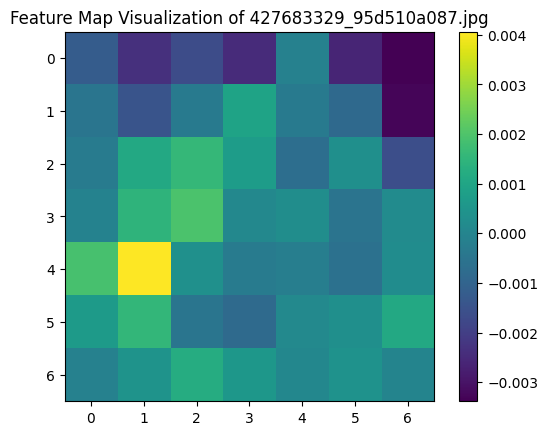

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Load extracted features
features_dict = np.load("drive/MyDrive/flickr8k_densenet169_features.npy", allow_pickle=True).item()
sample_image_name = list(features_dict.keys())[0]
sample_feature = features_dict[sample_image_name]

# Visualize one feature map channel
plt.imshow(sample_feature[0], cmap="viridis")  # Show first channel
plt.title(f"Feature Map Visualization of {sample_image_name}")
plt.colorbar()
plt.show()


In [ ]:
sample_feature.shape

(1664, 7, 7)

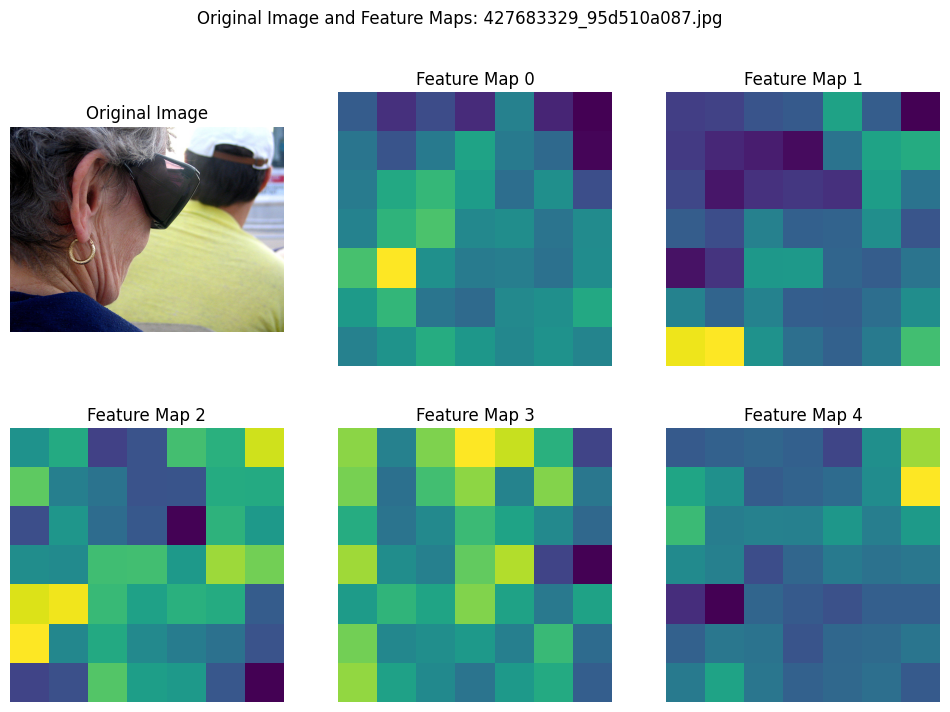

In [ ]:
image_path = os.path.join(path_to_images, sample_image_name)

# Load and display the original image
original_image = Image.open(image_path)

# Plot the original image and feature maps
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Show the original image
axes[0, 0].imshow(original_image)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

# Show 5 feature maps from DenseNet-169 output
for i, ax in enumerate(axes.flat[1:]):  # Skip the first subplot
    ax.imshow(sample_feature[i], cmap="viridis")
    ax.set_title(f"Feature Map {i}")
    ax.axis("off")

plt.suptitle(f"Original Image and Feature Maps: {sample_image_name}")
plt.show()

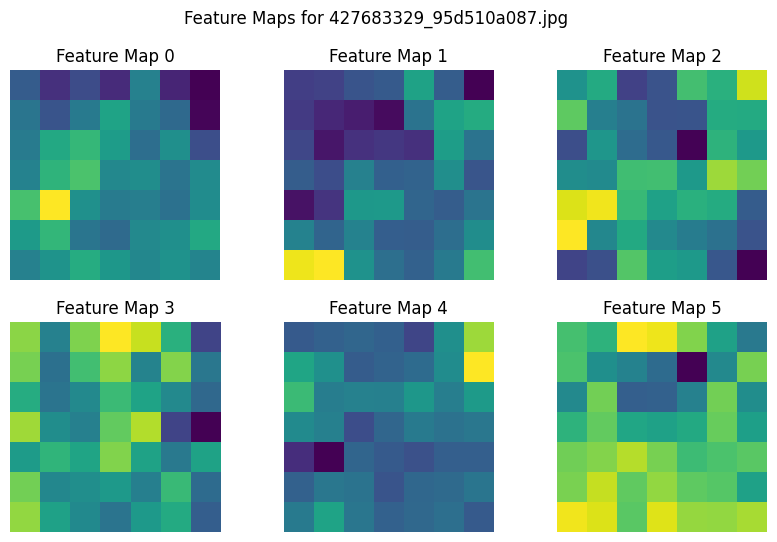

In [ ]:
# Select a few feature maps to visualize (e.g., first 6)
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_feature[i], cmap="viridis")
    ax.set_title(f"Feature Map {i}")
    ax.axis("off")

plt.suptitle(f"Feature Maps for {sample_image_name}")
plt.show()

In [2]:
import csv
import nltk
import re
import os
import numpy as np
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image


nltk.download("punkt")
nltk.download('punkt_tab')

# Load captions from file
captions_file = os.path.join(path, "captions.txt")

image_to_captions = {}

with open(captions_file, "r") as f:
    reader = csv.reader(f)
    next(reader)  # Skip header row
    for row in reader:
        img_name, caption = row
        caption = re.sub(r"[^a-zA-Z ]", "", caption.lower())  # Remove punctuation
        caption = nltk.tokenize.word_tokenize(caption)  # Tokenize

        # Store captions per image
        image_to_captions.setdefault(img_name, []).append(caption)

# Print sample
print("Sample processed captions:", list(image_to_captions.items())[0])

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Sample processed captions: ('1000268201_693b08cb0e.jpg', [['a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way'], ['a', 'girl', 'going', 'into', 'a', 'wooden', 'building'], ['a', 'little', 'girl', 'climbing', 'into', 'a', 'wooden', 'playhouse'], ['a', 'little', 'girl', 'climbing', 'the', 'stairs', 'to', 'her', 'playhouse'], ['a', 'little', 'girl', 'in', 'a', 'pink', 'dress', 'going', 'into', 'a', 'wooden', 'cabin']])


In [3]:
import re
from collections import Counter

# Build Vocabulary
word_freq = Counter()
for captions in image_to_captions.values():
    for caption in captions:
        word_freq.update(caption)

# Keep words with frequency ≥ 3
vocab = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"] + [word for word, freq in word_freq.items() if freq >= 3]
word_to_idx = {word: idx for idx, word in enumerate(vocab)}
idx_to_word = {idx: word for word, idx in word_to_idx.items()}

# Special tokens
PAD_IDX = word_to_idx["<PAD>"]
SOS_IDX = word_to_idx["<SOS>"]
EOS_IDX = word_to_idx["<EOS>"]

print(len(vocab))

4084


In [4]:
def caption_to_tensor(caption, max_length=20):
    tokens = [SOS_IDX] + [word_to_idx.get(word, word_to_idx["<UNK>"]) for word in caption] + [EOS_IDX]
    if len(tokens) < max_length:
        tokens += [PAD_IDX] * (max_length - len(tokens))  # Padding
    return torch.tensor(tokens[:max_length])  # Truncate if too long

In [19]:
import random
from sklearn.model_selection import train_test_split
class Flickr8kDataset(Dataset):
    def __init__(self, features_dict, image_to_captions, max_length=20):
        self.features_dict = features_dict
        self.image_to_captions = image_to_captions
        self.max_length = max_length
        self.image_names = list(features_dict.keys())  # Image filenames

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]

        feature_vector = torch.tensor(self.features_dict[image_name])  # Shape: (1664, 7, 7)
        # Flatten to (49, 1664) for attention
        feature_map = feature_vector.view(1664, -1).permute(1, 0)  # -> (49, 1664)

        # caption = caption_to_tensor(self.image_to_captions[image_name][0], self.max_length)  # Pick first caption
        # Randomly sample a caption for this image
        captions = self.image_to_captions[image_name]
        caption_text = random.choice(captions)
        caption = caption_to_tensor(caption_text, self.max_length)

        return feature_vector, caption

# Load extracted features
features_dict = np.load("drive/MyDrive/flickr8k_densenet169_features.npy", allow_pickle=True).item()

# Create dataset and dataloader
all_imgs = list(features_dict.keys())
train_imgs, temp_imgs = train_test_split(all_imgs, test_size=0.15, random_state=8)
val_imgs,   test_imgs = train_test_split(temp_imgs, test_size=0.1, random_state=8)

# Build per-split dicts
train_feats = {img: features_dict[img]       for img in train_imgs}
train_caps  = {img: image_to_captions[img]   for img in train_imgs}

val_feats   = {img: features_dict[img]       for img in val_imgs}
val_caps    = {img: image_to_captions[img]   for img in val_imgs}

test_feats  = {img: features_dict[img]       for img in test_imgs}
test_caps   = {img: image_to_captions[img]   for img in test_imgs}

# Create Datasets & DataLoaders
train_ds = Flickr8kDataset(train_feats, train_caps)
val_ds   = Flickr8kDataset(val_feats,   val_caps)
test_ds  = Flickr8kDataset(test_feats,  test_caps)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

Base Caption LSTM model

In [45]:
class CaptionLSTM(nn.Module):
    def __init__(self, feature_dim=1664, hidden_dim=512, vocab_size=len(vocab), embed_dim=256, num_layers=1):
        super(CaptionLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, vocab_size)

        # Add a Linear layer to transform the feature map into a single vector
        self.feature_projection = nn.Linear(feature_dim, embed_dim)

    def forward(self, features, captions):
        captions = captions[:, :-1]
        batch_size = features.size(0)

        features = features.mean(dim=(2, 3))

        # Transform features to match the embedding size
        features = self.feature_projection(features)  # Shape: (batch, embed_dim)
        # print("projected", features.shape)

        # Add an extra dimension to features so they align with LSTM input format
        features = features.unsqueeze(1)  # Shape: (batch, 1, embed_dim)
        # print("unsqueeze", features.shape)

        # Convert word indices to embeddings
        embeds = self.embedding(captions)  # Shape: (batch, seq_len, embed_dim)
        # print("embeds", embeds.shape)

        # Concatenate image features with captions as first time step
        lstm_input = torch.cat((features, embeds), dim=1)  # Shape: (batch, seq_len+1, embed_dim)
        # print("lstm_input", lstm_input.shape)

        # Pass through LSTM
        lstm_out, _ = self.lstm(lstm_input)
        outputs = self.fc(lstm_out)  # Shape: (batch, seq_len+1, vocab_size)
        # print("outputs", outputs.shape)

        return outputs

# Initialize model
model = CaptionLSTM()

LSTM with Bahdanau Attention

In [143]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, encoder_dim, decoder_dim, attn_dim):
        super().__init__()
        self.encoder_att = nn.Linear(encoder_dim, attn_dim)   # Wₐ·h_enc
        self.decoder_att = nn.Linear(decoder_dim, attn_dim)   # Uₐ·h_dec
        self.full_att    = nn.Linear(attn_dim, 1)             # vₐᵀ·tanh(...)

    def forward(self, encoder_out, hidden):
        # encoder_out: (batch, num_pixels, encoder_dim)
        # hidden:      (batch, decoder_dim)
        att1 = self.encoder_att(encoder_out)              # (batch, num_pixels, attn_dim)
        att2 = self.decoder_att(hidden).unsqueeze(1)      # (batch, 1, attn_dim)
        energy = torch.tanh(att1 + att2)                  # broadcast add
        scores = self.full_att(energy).squeeze(2)         # (batch, num_pixels)
        alpha  = F.softmax(scores, dim=1)                 # attention weights
        # context is weighted sum of encoder_out
        context = (encoder_out * alpha.unsqueeze(2)).sum(dim=1)  # (batch, encoder_dim)
        return context, alpha

class CaptionLSTMAttn(nn.Module):
    def __init__(self, feature_dim=1664, hidden_dim=512,
                 vocab_size=len(vocab), embed_dim=256, attn_dim=256):
        super().__init__()
        self.encoder_dim = feature_dim
        self.hidden_dim  = hidden_dim
        self.embed_dim   = embed_dim

        # 1) attention
        self.attention = BahdanauAttention(feature_dim, hidden_dim, attn_dim)

        # 2) embeddings + LSTMCell
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm_cell = nn.LSTMCell(embed_dim + feature_dim, hidden_dim)

        # 3) init hidden state from mean of features
        self.init_h = nn.Linear(feature_dim, hidden_dim)
        self.init_c = nn.Linear(feature_dim, hidden_dim)

        # 4) output -> vocab
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, features, captions):
        """
        features: (batch, feature_dim, 7, 7)
        captions: (batch, max_len)  # token IDs, including <SOS> at 0
        returns:
          outputs: (batch, max_len, vocab_size)
          alphas:  (batch, max_len, num_pixels)
        """
        batch_size, _, h, w = features.size()
        max_len = captions.size(1)

        # flatten spatial dims -> (batch, num_pixels=49, encoder_dim)
        encoder_out = features.view(batch_size, self.encoder_dim, -1) \
                              .permute(0, 2, 1)

        # initialize LSTM state
        mean_enc = encoder_out.mean(dim=1)  # (batch, encoder_dim)
        h_state = self.init_h(mean_enc)     # (batch, hidden_dim)
        c_state = self.init_c(mean_enc)     # (batch, hidden_dim)

        # embed captions (we will shift them inside the loop)
        embeddings = self.embedding(captions)  # (batch, max_len, embed_dim)

        outputs = torch.zeros(batch_size, max_len, self.fc.out_features, device=features.device)
        alphas  = torch.zeros(batch_size, max_len, encoder_out.size(1), device=features.device)

        for t in range(max_len):
            emb_t = embeddings[:, t, :]                     # (batch, embed_dim)

            # compute attention context using previous hidden
            context, alpha = self.attention(encoder_out, h_state)

            # LSTMCell input = [emb_t; context]
            lstm_input = torch.cat([emb_t, context], dim=1)  # (batch, embed_dim+encoder_dim)
            h_state, c_state = self.lstm_cell(lstm_input, (h_state, c_state))

            preds = self.fc(h_state)                         # (batch, vocab_size)
            outputs[:, t, :] = preds
            alphas[:, t, :]  = alpha

        return outputs, alphas

model = CaptionLSTMAttn()

Transformer Decoder

In [180]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CaptionTransformer(nn.Module):
    def __init__(
        self,
        feature_dim=1664,
        vocab_size=len(vocab),
        embed_dim=256,
        num_heads=8,
        num_layers=3,
        ff_dim=1024,
        max_len=20,
        dropout=0.1,
    ):
        super().__init__()
        self.feature_dim = feature_dim
        self.embed_dim   = embed_dim
        self.max_len     = max_len

        # 1) project CNN features -> decoder embedding dim
        self.feature_proj = nn.Linear(feature_dim, embed_dim)

        # 2) learned positional encodings for the image memory (49 positions) and captions
        self.pos_enc_img = nn.Parameter(torch.zeros(1, 49, embed_dim))
        self.pos_enc_txt = nn.Parameter(torch.zeros(1, max_len, embed_dim))

        # 3) token embedding for captions
        self.token_emb = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # 4) transformer decoder
        dec_layer = nn.TransformerDecoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            activation="relu",
        )
        self.transformer_decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        # 5) output head
        self.fc_out = nn.Linear(embed_dim, vocab_size)

    def generate_square_subsequent_mask(self, sz):
        # mask so that position i can only attend to [0..i]
        mask = torch.triu(torch.ones(sz, sz), diagonal=1).bool()
        return mask

    def forward(self, features, captions):
        """
        features: (batch, 1664, 7, 7)
        captions: (batch, max_len)  # with <SOS>...<EOS>/PAD
        returns:  logits (batch, max_len, vocab_size)
        """
        batch_size = features.size(0)

        # —————————— IMAGE MEMORY ——————————
        # flatten to (batch, 49, 1664)
        img_seq = features.view(batch_size, self.feature_dim, -1).permute(0, 2, 1)
        # project -> (batch, 49, embed_dim)
        img_mem = self.feature_proj(img_seq)
        # add positional encoding (only first 49 positions)
        img_mem = img_mem + self.pos_enc_img[:, : img_mem.size(1), :]
        # transformer wants (seq_len, batch, embed_dim)
        memory = img_mem.permute(1, 0, 2)  # (49, batch, embed_dim)

        # —————————— TEXT TARGETS ——————————
        # shift captions right: drop last token so we predict it
        tgt = captions[:, :-1]                           # (batch, max_len-1)
        seq_len = tgt.size(1)

        # embed + pos-enc -> (batch, seq_len, embed_dim)
        tgt_emb = self.token_emb(tgt) + self.pos_enc_txt[:, :seq_len, :]
        # permute to (seq_len, batch, embed_dim)
        tgt_emb = tgt_emb.permute(1, 0, 2)

        # create causal mask so position i can’t see Future tokens
        tgt_mask = self.generate_square_subsequent_mask(seq_len).to(features.device)

        # —————— TRANSFORMER DECODER ——————
        dec_out = self.transformer_decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        # (seq_len, batch, embed_dim)

        # project back to vocab
        dec_out = dec_out.permute(1, 0, 2)  # (batch, seq_len, embed_dim)
        logits  = self.fc_out(dec_out)      # (batch, seq_len, vocab_size)

        # pad back to max_len by adding a dummy first <SOS> step if you like;
        # but for training you can simply compare logits[:, :seq_len, :] to captions[:, 1:]
        return logits

model = CaptionTransformer()

In [181]:
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
name = type(model).__name__

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 30
for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for features, captions in train_loader:
        # Move to GPU/CPU
        features = features.to(device)             # (batch, feat_dim, 7, 7)
        captions = captions.to(device)             # (batch, seq_len)

        if name == 'CaptionLSTM':
          outputs = model(features, captions)

          outputs = outputs.reshape(-1, len(vocab))  # Flatten the output to (batch_size * seq_len, vocab_size)
          targets = captions.reshape(-1)  # Flatten the target to (batch_size * seq_len)

        elif name == 'CaptionLSTMAttn':
          inputs  = captions[:, :-1]                 # (batch, seq_len-1)
          targets = captions[:,  1:]                 # (batch, seq_len-1)

          outputs, _ = model(features, inputs)

          b, t, v = outputs.shape
          outputs = outputs.reshape(b * t, v)
          targets = targets.reshape(b * t)

        elif name == 'CaptionTransformer':
          outputs = model(features, captions)

          targets = captions[:,  1:]

          b, t, v = outputs.shape
          outputs = outputs.reshape(b * t, v)
          targets = targets.reshape(b * t)

        loss = criterion(outputs, targets)

        # 4) Backward + optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    # -------- Validation --------
    model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for features, captions in val_loader:
            features = features.to(device)
            captions = captions.to(device)

            if name == 'CaptionLSTM':
                outputs = model(features, captions)
                outputs = outputs.reshape(-1, len(vocab))
                targets = captions.reshape(-1)

            elif name == 'CaptionLSTMAttn':
                inputs = captions[:, :-1]
                targets = captions[:, 1:]
                outputs, _ = model(features, inputs)
                b, t, v = outputs.shape
                outputs = outputs.reshape(b * t, v)
                targets = targets.reshape(b * t)

            elif name == 'CaptionTransformer':
                outputs = model(features, captions)
                targets = captions[:, 1:]
                b, t, v = outputs.shape
                outputs = outputs.reshape(b * t, v)
                targets = targets.reshape(b * t)

            val_loss = criterion(outputs, targets)
            total_val_loss += val_loss.item()

    avg_val_loss = total_val_loss / len(val_loader)

    # --------- Print losses --------
    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {avg_train_loss:.4f}  Val Loss: {avg_val_loss:.4f}")

Epoch [1/30]  Train Loss: 4.2356  Val Loss: 3.6308
Epoch [2/30]  Train Loss: 3.4430  Val Loss: 3.4023
Epoch [3/30]  Train Loss: 3.2353  Val Loss: 3.2490
Epoch [4/30]  Train Loss: 3.0712  Val Loss: 3.1897
Epoch [5/30]  Train Loss: 2.9675  Val Loss: 3.1541
Epoch [6/30]  Train Loss: 2.9047  Val Loss: 3.1533
Epoch [7/30]  Train Loss: 2.8249  Val Loss: 3.1006
Epoch [8/30]  Train Loss: 2.7621  Val Loss: 3.1001
Epoch [9/30]  Train Loss: 2.7415  Val Loss: 3.0503
Epoch [10/30]  Train Loss: 2.6715  Val Loss: 3.0665
Epoch [11/30]  Train Loss: 2.6412  Val Loss: 3.0815
Epoch [12/30]  Train Loss: 2.6017  Val Loss: 3.0721
Epoch [13/30]  Train Loss: 2.5737  Val Loss: 3.0596
Epoch [14/30]  Train Loss: 2.5538  Val Loss: 3.0787
Epoch [15/30]  Train Loss: 2.5054  Val Loss: 3.0269
Epoch [16/30]  Train Loss: 2.4833  Val Loss: 3.0738
Epoch [17/30]  Train Loss: 2.4509  Val Loss: 3.0215
Epoch [18/30]  Train Loss: 2.4333  Val Loss: 3.0242
Epoch [19/30]  Train Loss: 2.4167  Val Loss: 3.0063
Epoch [20/30]  Train 

Base LSTM Beam Search

In [154]:
def beam_search_caption(model, image_feature, vocab, beam_width=3, max_length=20):
    model.eval()
    device = next(model.parameters()).device

    if not torch.is_tensor(image_feature):
        image_feature = torch.tensor(image_feature)
    image_feature = image_feature.unsqueeze(0).to(device)

    with torch.no_grad():
        pooled_feature = image_feature.mean(dim=(2, 3))  # Global average pooling
        # print(pooled_feature.shape)
        # flat = image_feature.view(image_feature.size(0), -1)  # shape: (batch, 81536)
        # print(flat.shape)
        # feature_proj = model.feature_projection(flat)
        # print(feature_proj.shape)
        feature_proj = model.feature_projection(pooled_feature)

    # Initialize beams with start token
    beams = [([SOS_IDX], 0.0, None)]  # (current_caption, cumulative_log_prob, hidden_state)

    for _ in range(max_length):
        new_beams = []
        for caption, score, hidden in beams:
            if caption[-1] == EOS_IDX:
                new_beams.append((caption, score, hidden))
                continue

            caption_tensor = torch.tensor(caption).unsqueeze(0).to(device)
            embedded = model.embedding(caption_tensor)
            if len(caption) == 1:
                lstm_input = torch.cat((feature_proj.unsqueeze(1), embedded), dim=1)
            else:
                lstm_input = embedded

            lstm_out, hidden_new = model.lstm(lstm_input, hidden)
            output = model.fc(lstm_out[:, -1, :])
            log_probs = torch.log_softmax(output, dim=-1).squeeze(0)

            # Expand beam candidates
            topk_log_probs, topk_indices = log_probs.topk(beam_width)
            for k in range(beam_width):
                new_caption = caption + [topk_indices[k].item()]
                new_score = score + topk_log_probs[k].item()
                new_beams.append((new_caption, new_score, hidden_new))

        # Keep top beam_width beams
        beams = sorted(new_beams, key=lambda x: x[1], reverse=True)[:beam_width]
        # If all beams end with EOS, break
        if all(b[0][-1] == EOS_IDX for b in beams):
            break

    # Select the best caption (excluding the start token)
    best_caption = beams[0][0][1:]
    caption_words = [vocab[token] for token in best_caption if token not in {EOS_IDX, PAD_IDX}]
    return " ".join(caption_words)

# Example usage:
sample_image_name = list(features_dict.keys())[32]
sample_image_name = test_loader.dataset.image_names[-1]
sample_feature = features_dict[sample_image_name]
generated_caption = beam_search_caption(model, sample_feature, vocab, beam_width=10)
print(f"Beam Search Caption for {sample_image_name}: {generated_caption}")

AttributeError: 'CaptionLSTMAttn' object has no attribute 'feature_projection'

Attention Beam Search

In [178]:
import torch
import torch.nn.functional as F

def beam_search_attn(model, feature,
                     beam_width=3, max_length=20):
    """
    feature:    (feature_dim, 7, 7)  single image
    returns:    list of token IDs for best caption
    """
    model.eval()
    device = next(model.parameters()).device
    # Prepare encoder features
    if not torch.is_tensor(feature):
        feature = torch.tensor(feature)
    feat = feature.unsqueeze(0).to(device)

    batch_size = 1

    # Precompute encoder_out
    encoder_out = feat.view(1, model.encoder_dim, -1).permute(0,2,1)  # (1,49,feat_dim)

    # Init hidden states
    mean_enc = encoder_out.mean(dim=1)  # (1,feat_dim)
    h0 = model.init_h(mean_enc)         # (1,hidden_dim)
    c0 = model.init_c(mean_enc)         # (1,hidden_dim)

    # Beam: each entry is (seq, h, c, log_prob, ended_flag)
    beam = [([SOS_IDX], h0, c0, 0.0, False)]

    for _ in range(max_length):
        candidates = []
        for seq, h, c, logp, ended in beam:
            if ended:
                # already ended, carry forward
                candidates.append((seq, h, c, logp, True))
                continue

            # last token
            prev = torch.tensor([seq[-1]], device=device).unsqueeze(0)  # (1,1)
            emb = model.embedding(prev).squeeze(1)                      # (1,embed_dim)

            # attention & LSTMCell
            context, _ = model.attention(encoder_out.repeat(1,1,1), h)  # (1, feat_dim)
            inp = torch.cat([emb, context], dim=1)                     # (1,embed+feat)
            h_new, c_new = model.lstm_cell(inp, (h, c))

            # predict next
            logits = model.fc(h_new)                                   # (1,vocab_size)
            log_probs = F.log_softmax(logits, dim=1).squeeze(0)        # (vocab_size,)

            topk_logp, topk_idx = log_probs.topk(beam_width)
            for lp, idx in zip(topk_logp.tolist(), topk_idx.tolist()):
                new_seq = seq + [idx]
                ended_flag = (idx == EOS_IDX)
                candidates.append((new_seq, h_new, c_new, logp + lp, ended_flag))

        # select top beam_size by log_prob
        candidates.sort(key=lambda x: x[3], reverse=True)
        beam = candidates[:beam_width]

        # if all beams ended, stop
        if all(b[4] for b in beam):
            break

    # best beam
    best_seq = beam[0][0]

    # convert IDs -> words
    words = []
    for idx in best_seq:
        if idx == EOS_IDX: break
        if idx != SOS_IDX:
            words.append(idx_to_word[idx])
    generated_caption = ' '.join(words)

    return generated_caption

# Example usage:
sample_image_name = list(features_dict.keys())[32]
sample_image_name = test_loader.dataset.image_names[38]
sample_feature = features_dict[sample_image_name]
generated_caption = beam_search_attn(model, sample_feature, beam_width=10, max_length=20)
print(f"Beam Search Caption for {sample_image_name}: {generated_caption}")

Beam Search Caption for 381275595_b429fd1639.jpg: a brown dog is jumping over a hurdle


Transformer Beam Search

In [248]:
import torch
import torch.nn.functional as F

def beam_search_tf(
    model,
    feature,
    beam_width: int = 3,
    max_length: int = 20):
    """
    Beam‐search decoding for CaptionTransformer.
    Args:
      model       : your trained CaptionTransformer
      feature     : single image feature (np.array or torch.Tensor) shape (feature_dim, 7, 7)
      vocab       : list of tokens, e.g. ["<PAD>", "<SOS>", ...]
      beam_width  : beam size
      max_len     : maximum caption length (including <SOS>, <EOS>)
      device      : 'cuda' or 'cpu'
    Returns:
      Generated caption string (words joined by spaces)
    """
    model.eval()

    # Prepare feature -> memory
    if not torch.is_tensor(feature):
        feature = torch.tensor(feature, dtype=torch.float32)
    feature = feature.unsqueeze(0).to(device)                   # (1, feat_dim, 7, 7)
    b, fd, h, w = feature.size()

    # flatten & project
    img_seq = feature.view(b, fd, -1).permute(0, 2, 1)          # (1, 49, feat_dim)
    img_mem = model.feature_proj(img_seq)                       # (1, 49, embed_dim)
    img_mem = img_mem + model.pos_enc_img[:, :49, :]            # add positional
    memory = img_mem.permute(1, 0, 2)                           # (49, 1, embed_dim)

    # initialize beams: (seq, log_prob, ended_flag)
    beams = [([SOS_IDX], 0.0, False)]

    with torch.no_grad():
        for _ in range(max_length):
            candidates = []
            for seq, logp, ended in beams:
                if ended:
                    candidates.append((seq, logp, True))
                    continue

                # prepare decoder input
                seq_tensor = torch.tensor(seq, device=device).unsqueeze(0)  # (1, seq_len)
                seq_len = seq_tensor.size(1)

                # embed + positional
                tgt_emb = model.token_emb(seq_tensor) + model.pos_enc_txt[:, :seq_len, :]
                tgt_emb = tgt_emb.permute(1, 0, 2)                         # (seq_len, 1, embed_dim)

                # causal mask
                mask = model.generate_square_subsequent_mask(seq_len).to(device)

                # run decoder one step
                dec_out = model.transformer_decoder(tgt_emb, memory, tgt_mask=mask)
                # dec_out: (seq_len, 1, embed_dim)
                logits = model.fc_out(dec_out.permute(1, 0, 2))            # (1, seq_len, vocab_size)
                last_logits = logits[:, -1, :]                             # (1, vocab_size)
                log_probs = F.log_softmax(last_logits, dim=-1).squeeze(0)  # (vocab_size,)

                # expand beam
                topk_logp, topk_idx = log_probs.topk(beam_width)
                for lp, idx in zip(topk_logp.tolist(), topk_idx.tolist()):
                    new_seq = seq + [idx]
                    new_logp = logp + lp
                    new_ended = (idx == EOS_IDX)
                    candidates.append((new_seq, new_logp, new_ended))

            # prune to top beam_width
            beams = sorted(candidates, key=lambda x: x[1], reverse=True)[:beam_width]
            # if all beams have ended, stop early
            if all(ended for _, _, ended in beams):
                break

    # pick best beam
    best_seq = beams[0][0]
    # convert to words, strip SOS/EOS
    words = []
    for idx in best_seq:
        if idx == SOS_IDX: continue
        if idx == EOS_IDX: break
        words.append(idx_to_word.get(idx, "<UNK>"))

    return " ".join(words)

sample_image_name = list(features_dict.keys())[31]
sample_image_name = test_loader.dataset.image_names[65]
sample_feature = features_dict[sample_image_name]

generated_caption = beam_search_tf(
    model,
    sample_feature,
    beam_width=10,
    max_length=20)
print(f"Beam Search Caption for {sample_image_name}: {generated_caption}")

Beam Search Caption for 1679557684_50a206e4a9.jpg: a white dog runs across the grass


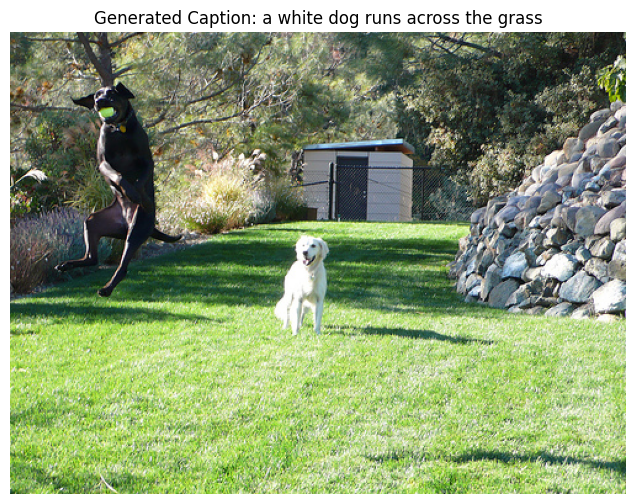

Ground-Truth Captions for 1679557684_50a206e4a9.jpg:
1. a big black dog jumps in the air to catch the tennis ball in his mouth
2. a dog looks at another dog catching a ball in the air
3. a white dog is watching a black dog jump on a lawn next to a pile of large rocks
4. a white dog watching a black dog in the air
5. two dogs playing with a tennis ball in the yard


In [249]:
import matplotlib.pyplot as plt
import os
from PIL import Image

# Define the path to your image folder
image_path = os.path.join(path_to_images, sample_image_name)
original_image = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(original_image)
plt.axis("off")
plt.title(f"Generated Caption: {generated_caption}", fontsize=12)
plt.show()

# Print the ground-truth captions in the console
print(f"Ground-Truth Captions for {sample_image_name}:")
for i, caption in enumerate(image_to_captions[sample_image_name]):
    joined = " ".join(caption)
    print(f"{i+1}. {joined}")

In [ ]:
import torch
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

model.eval()
references = []  # List of lists of reference captions tokens
hypotheses = []  # List of generated caption tokens
smooth_fn = SmoothingFunction().method1

counter = 0
with torch.no_grad():
    for features, _ in test_loader:
        features = features.to(device)      # (batch, 1664, 7, 7)
        bs = features.size(0)
        for i in range(bs):
            feat = features[i]              # (1664,7,7)
            # Generate caption
            if name == 'CaptionLSTM':
              generated_caption = beam_search_caption(model, sample_feature, vocab, beam_width=10)
            elif name == 'CaptionLSTMAttn':
              generated_caption = beam_search_attn(model, sample_feature, beam_width=10)
            elif name == 'CaptionTransformer':
              generated_caption = beam_search_tf(model, sample_feature, beam_width=10)
            # Tokenize the generated caption (simple whitespace tokenization)
            hypothesis_tokens = generated_caption.split()
            hypotheses.append(hypothesis_tokens)

            # Retrieve ground truth captions and tokenize each reference caption
            img_name = test_loader.dataset.image_names[counter]
            references.append(test_loader.dataset.image_to_captions[img_name])

            counter += 1

# Use smoothing for better BLEU score estimation on short sentences
smooth_fn = SmoothingFunction().method1

# Compute corpus-level BLEU scores
bleu1 = corpus_bleu(references, hypotheses, weights=(1, 0, 0, 0), smoothing_function=smooth_fn)
bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth_fn)
bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth_fn)
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth_fn)

print("Quantitative Evaluation on Test Loader:")
print(f"  BLEU-1: {bleu1:.4f}")
print(f"  BLEU-2: {bleu2:.4f}")
print(f"  BLEU-3: {bleu3:.4f}")
print(f"  BLEU-4: {bleu4:.4f}")